In [18]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [19]:
# Google Drive file ID and download URL
file_id = "1JEflC5W9gV0Z039OYCT2hOxE9G9KsqOj"
url = f"https://drive.google.com/uc?id={file_id}"

# Download the file
output = "cleaned_p2p_lending_data.csv"
gdown.download(url, output, quiet=False)

# Read the CSV into a DataFrame
df = pd.read_csv(output)
df.head()

Downloading...
From (original): https://drive.google.com/uc?id=1JEflC5W9gV0Z039OYCT2hOxE9G9KsqOj
From (redirected): https://drive.google.com/uc?id=1JEflC5W9gV0Z039OYCT2hOxE9G9KsqOj&confirm=t&uuid=1cd892fc-98c6-4651-96ec-4ad9b60b84d0
To: d:\GitHub\ET6-CDSP-group-15-repo\4_data_analysis\cleaned_p2p_lending_data.csv
100%|██████████| 279M/279M [00:23<00:00, 12.1MB/s] 


,loan_amnt,term,int_rate,annual_inc,dti,delinq_2yrs,inq_last_6mths,emp_length,fico_range_low,fico_range_high,...,addr_state_WV,addr_state_WY,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,credit_history_length
0,3600.0,36,13.99,55000.0,5.91,0.0,1.0,10,675.0,679.0,...,0,0,0,0,1,0,0,0,0,150.0
1,24700.0,36,11.99,65000.0,16.06,1.0,4.0,10,715.0,719.0,...,0,0,0,0,1,0,0,0,0,195.0
2,20000.0,60,10.78,63000.0,10.78,0.0,0.0,10,695.0,699.0,...,0,0,0,1,0,0,0,0,0,187.0
3,10400.0,60,22.45,104433.0,25.37,1.0,3.0,3,695.0,699.0,...,0,0,0,0,0,0,0,1,0,213.0
4,11950.0,36,13.44,34000.0,10.20,0.0,0.0,4,690.0,694.0,...,0,0,0,0,1,0,0,0,0,343.0


In [21]:
# 1. Basic Information
print("Dataset Shape:", df.shape)
print("\nData Types and Missing Values:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1265557, 84)

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1265557 entries, 0 to 1265556
Data columns (total 84 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   loan_amnt                   1265557 non-null  float64
 1   term                        1265557 non-null  int64  
 2   int_rate                    1265557 non-null  float64
 3   annual_inc                  1265557 non-null  float64
 4   dti                         1265557 non-null  float64
 5   delinq_2yrs                 1265557 non-null  float64
 6   inq_last_6mths              1265557 non-null  float64
 7   emp_length                  1265557 non-null  int64  
 8   fico_range_low              1265557 non-null  float64
 9   fico_range_high             1265557 non-null  float64
 10  open_acc                    1265557 non-null  float64
 11  pub_rec                     1265557 non-null  float64


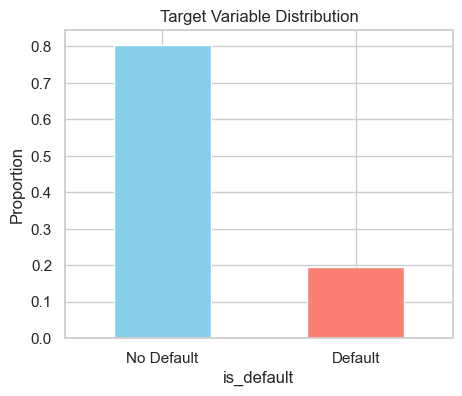

In [22]:
# 2. Target Distribution
plt.figure(figsize=(5, 4))
df["is_default"].value_counts(normalize=True).plot(
    kind="bar", color=["skyblue", "salmon"]
)
plt.title("Target Variable Distribution")
plt.xlabel("is_default")
plt.ylabel("Proportion")
plt.xticks(ticks=[0, 1], labels=["No Default", "Default"], rotation=0)
plt.show()


Numerical Features Summary:
          loan_amnt      int_rate    annual_inc           dti   delinq_2yrs  \
count  1.265557e+06  1.265557e+06  1.265557e+06  1.265557e+06  1.265557e+06   
mean   1.460310e+04  1.323245e+01  7.788790e+04  1.813101e+01  3.213336e-01   
std    8.745474e+03  4.769235e+00  7.102512e+04  9.569814e+00  8.833241e-01   
min    5.000000e+02  5.310000e+00  3.300000e+01  0.000000e+00  0.000000e+00   
25%    8.000000e+03  9.750000e+00  4.800000e+04  1.176000e+01  0.000000e+00   
50%    1.210000e+04  1.274000e+01  6.500000e+04  1.752000e+01  0.000000e+00   
75%    2.000000e+04  1.599000e+01  9.250000e+04  2.391000e+01  0.000000e+00   
max    4.000000e+04  3.099000e+01  1.099920e+07  9.990000e+02  3.900000e+01   

       inq_last_6mths  fico_range_low  fico_range_high      open_acc  \
count    1.265557e+06    1.265557e+06     1.265557e+06  1.265557e+06   
mean     6.568270e-01    6.961156e+02     7.001157e+02  1.167684e+01   
std      9.393550e-01    3.165674e+01     3

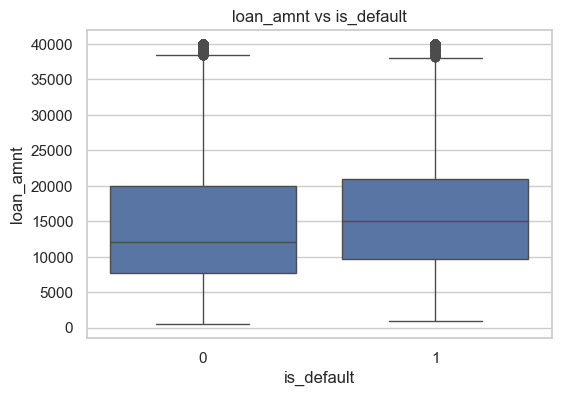

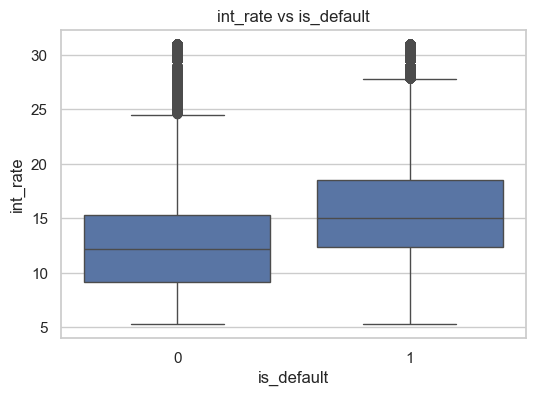

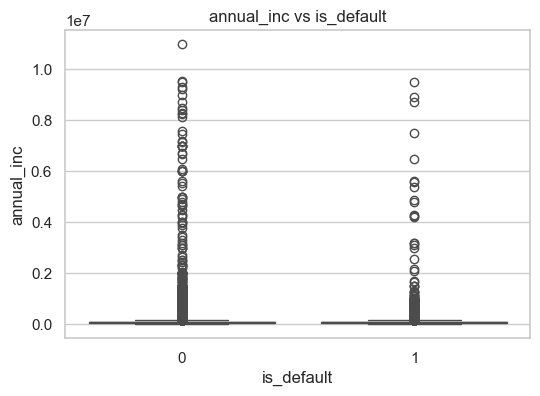

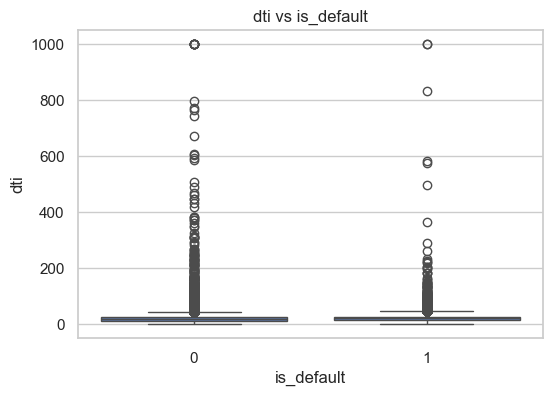

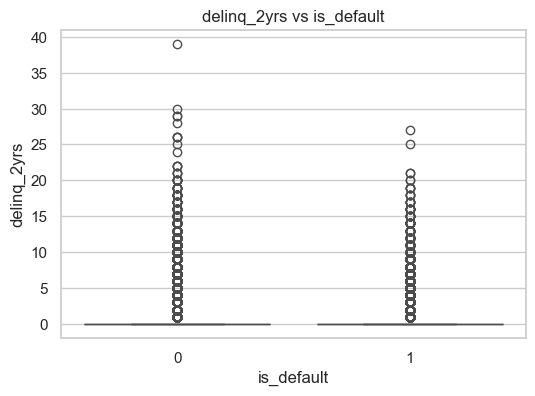

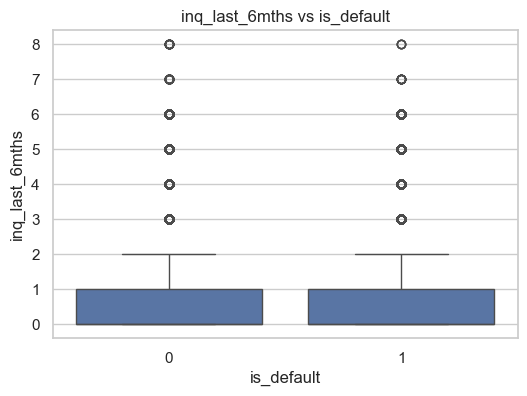

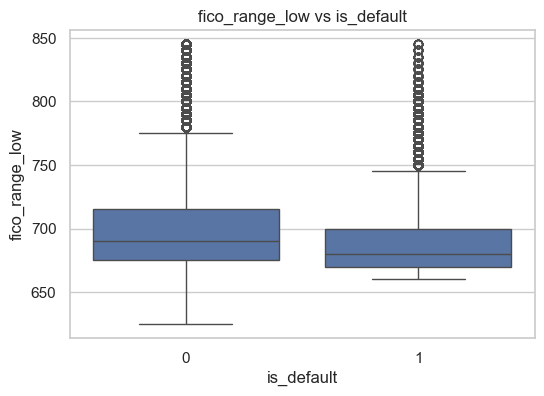

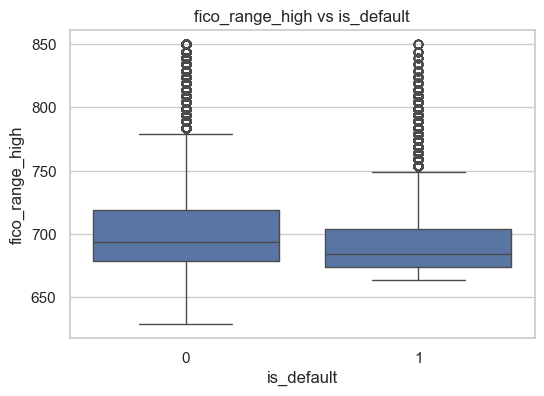

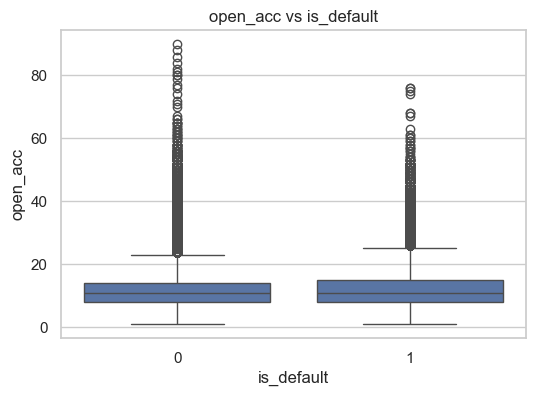

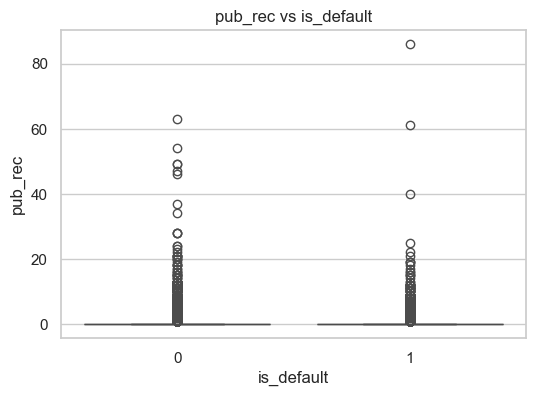

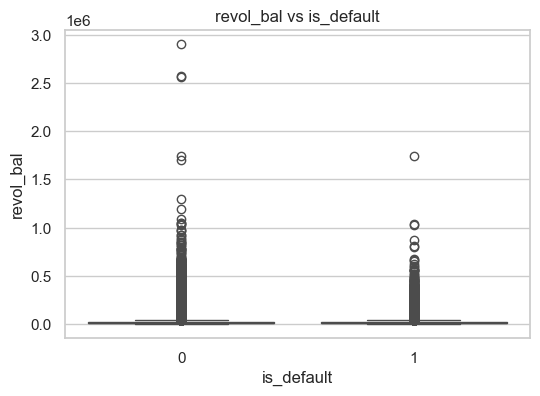

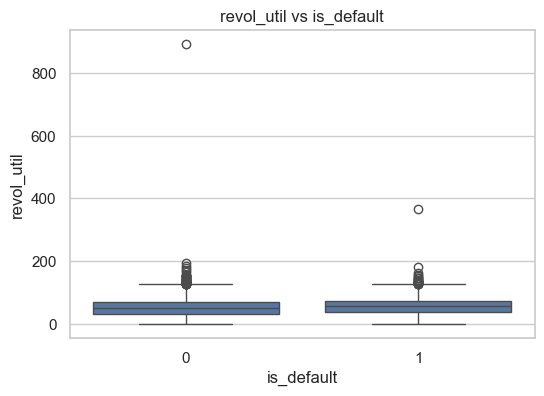

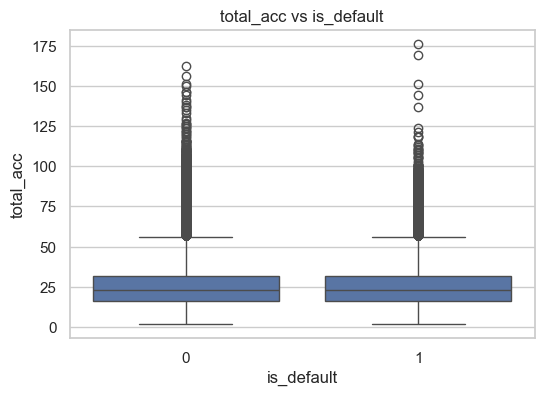

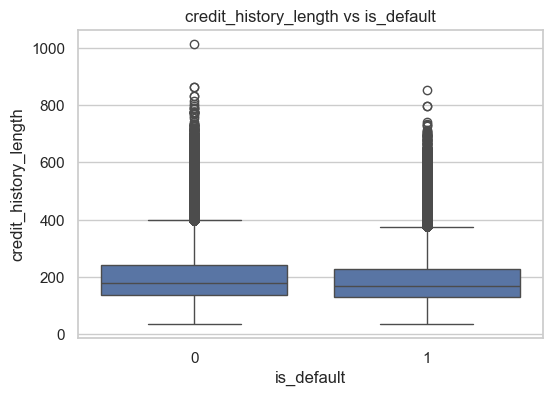

In [23]:
# 3. Numerical Features Overview
num_cols = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "fico_range_low",
    "fico_range_high",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "credit_history_length",
]

print("\nNumerical Features Summary:")
print(df[num_cols].describe())

# Boxplots by is_default
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="is_default", y=col, data=df)
    plt.title(f"{col} vs is_default")
    plt.show()

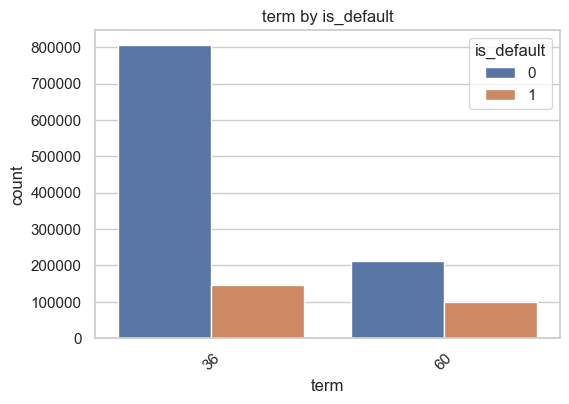

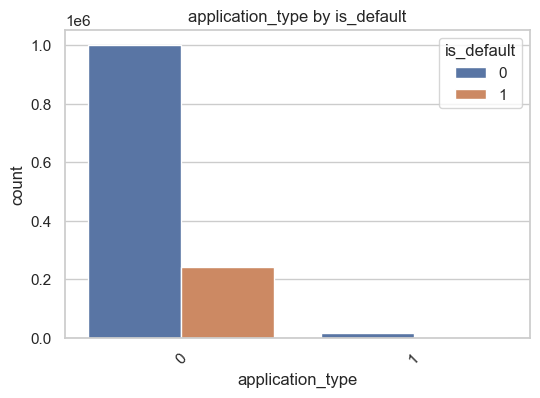

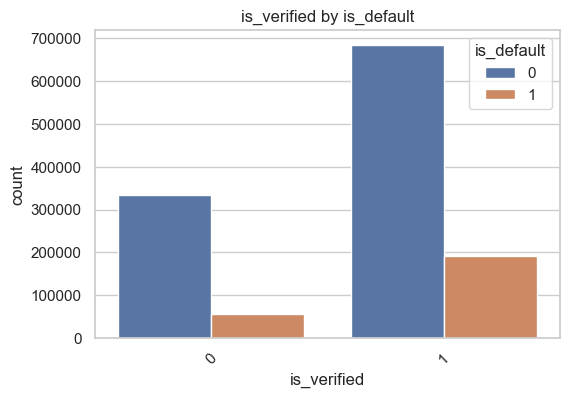

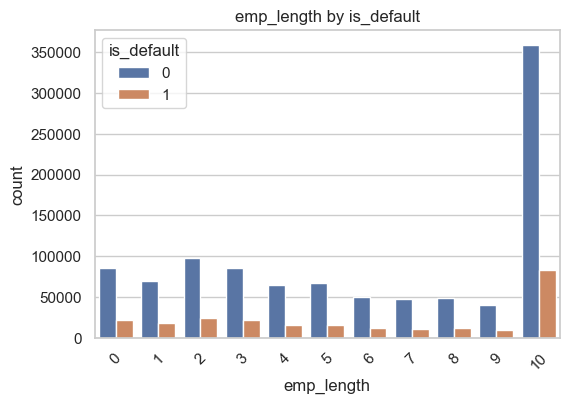

In [24]:
# 4. Categorical Features
cat_cols = ["term", "application_type", "is_verified", "emp_length"]
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue="is_default", data=df)
    plt.title(f"{col} by is_default")
    plt.xticks(rotation=45)
    plt.show()

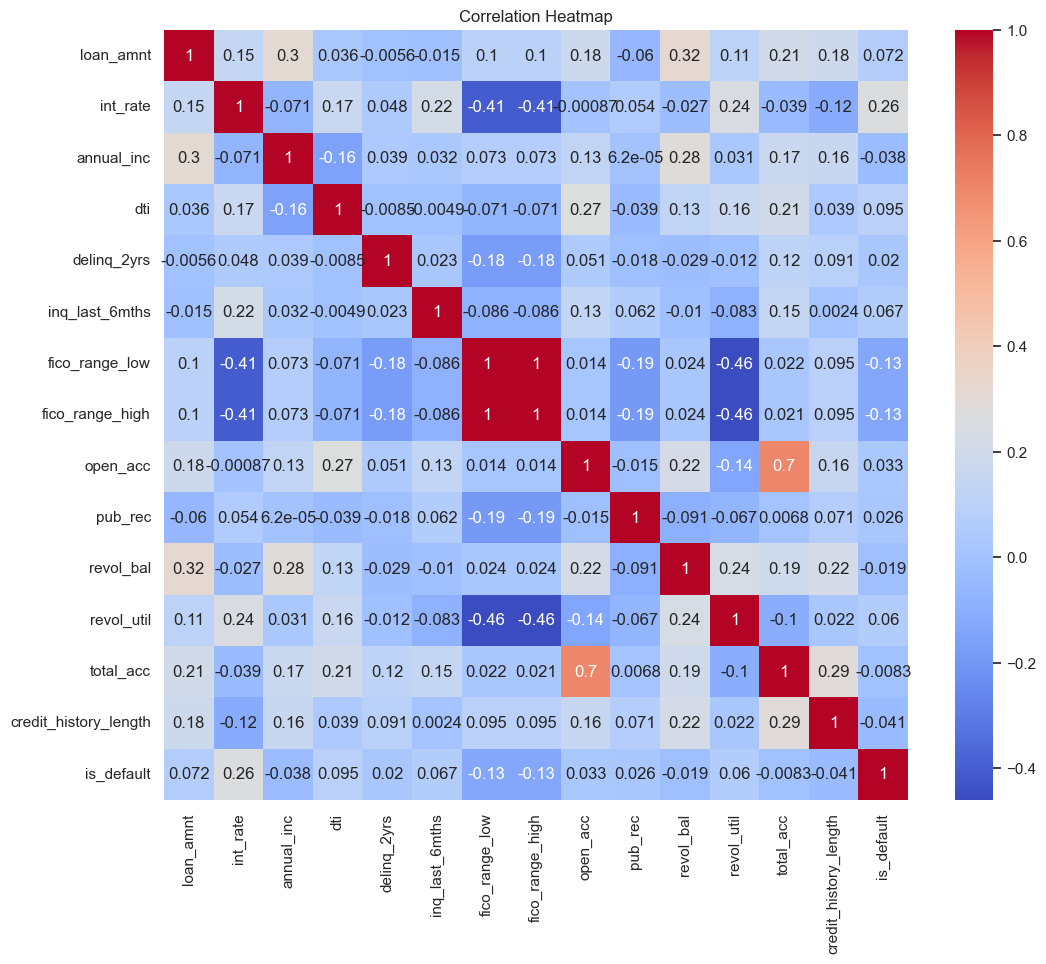

In [25]:
# 5. Correlation Heatmap
plt.figure(figsize=(12, 10))
corr = df[num_cols + ["is_default"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Outliers per numerical column:
 [    0  9151  9611  2728 34781 18699 17842 17842 14668 11680 16070    77
 11747 14214]


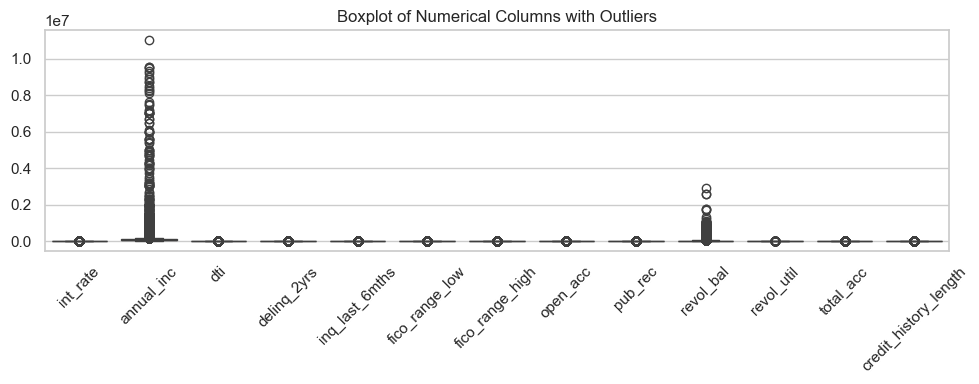

In [38]:
# 6. Outlier Detection
from scipy.stats import zscore

z_scores = np.abs(zscore(df[num_cols]))
outliers = (z_scores > 3).sum(axis=0)
print("Outliers per numerical column:\n", outliers)

plt.figure(figsize=(10, 4))
# Select columns with outliers
outlier_cols = [col for col, count in zip(num_cols, outliers) if count > 0]
sns.boxplot(data=df[outlier_cols])
plt.title("Boxplot of Numerical Columns with Outliers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2212\3623279500.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_corr.values, y=grade_corr.index, palette="viridis")


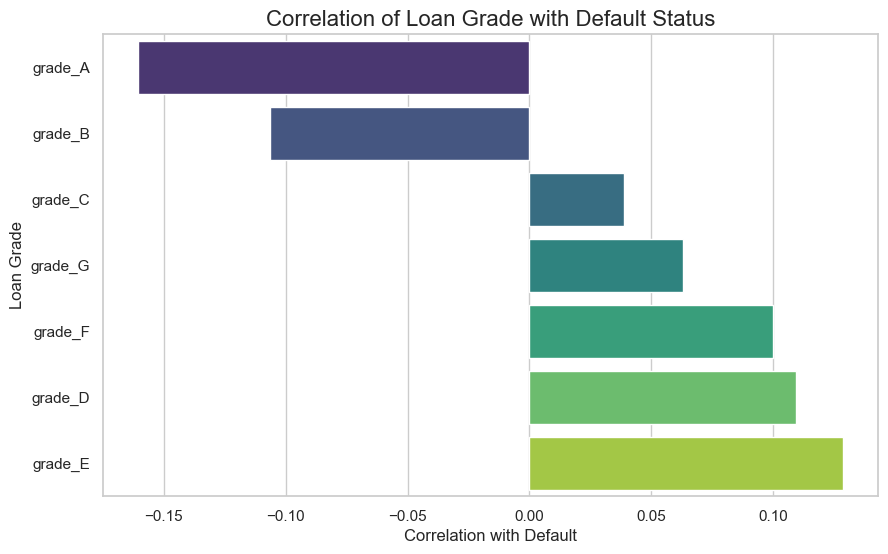

In [28]:
grade_cols = [col for col in df.columns if col.startswith("grade_")]
if grade_cols:
    grade_corr = df[grade_cols + ["is_default"]].corr()["is_default"].sort_values()
    grade_corr = grade_corr.drop("is_default")  # Exclude the target itself
    plt.figure(figsize=(10, 6))
    sns.barplot(x=grade_corr.values, y=grade_corr.index, palette="viridis")
    plt.title("Correlation of Loan Grade with Default Status", fontsize=16)
    plt.xlabel("Correlation with Default", fontsize=12)
    plt.ylabel("Loan Grade", fontsize=12)
    plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2212\1746856808.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=purposes_corr.values, y=purposes_corr.index, palette="viridis")


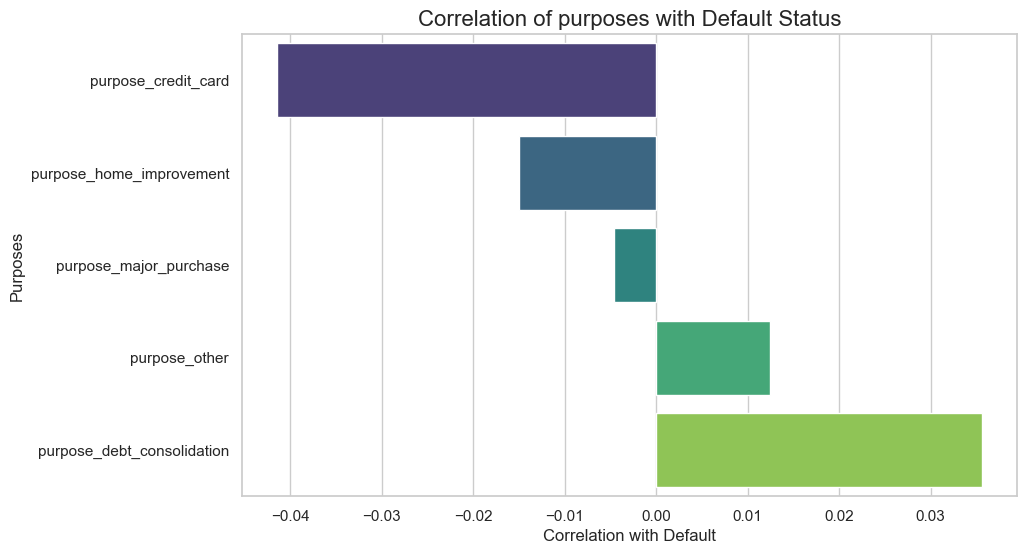

In [43]:
purposes_cols = [col for col in df.columns if col.startswith("purpose_")]
if purposes_cols:
    purposes_corr = (
        df[purposes_cols + ["is_default"]].corr()["is_default"].sort_values()
    )
    purposes_corr = purposes_corr.drop("is_default")  # Exclude the target itself
    plt.figure(figsize=(10, 6))
    sns.barplot(x=purposes_corr.values, y=purposes_corr.index, palette="viridis")
    plt.title("Correlation of purposes with Default Status", fontsize=16)
    plt.xlabel("Correlation with Default", fontsize=12)
    plt.ylabel("Purposes", fontsize=12)
    plt.show()

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


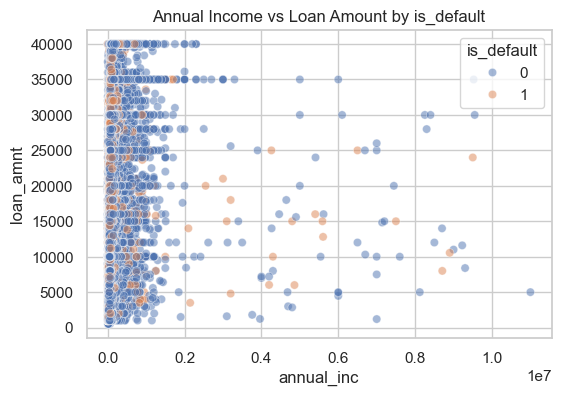

In [33]:
# 8. Bivariate Analysis (Example: Does high income + high loan_amnt affect default more?)
plt.figure(figsize=(6, 4))
sns.scatterplot(x="annual_inc", y="loan_amnt", hue="is_default", data=df, alpha=0.5)
plt.title("Annual Income vs Loan Amount by is_default")
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2212\1391676969.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=addr_corr.values, y=addr_corr.index, palette="viridis")


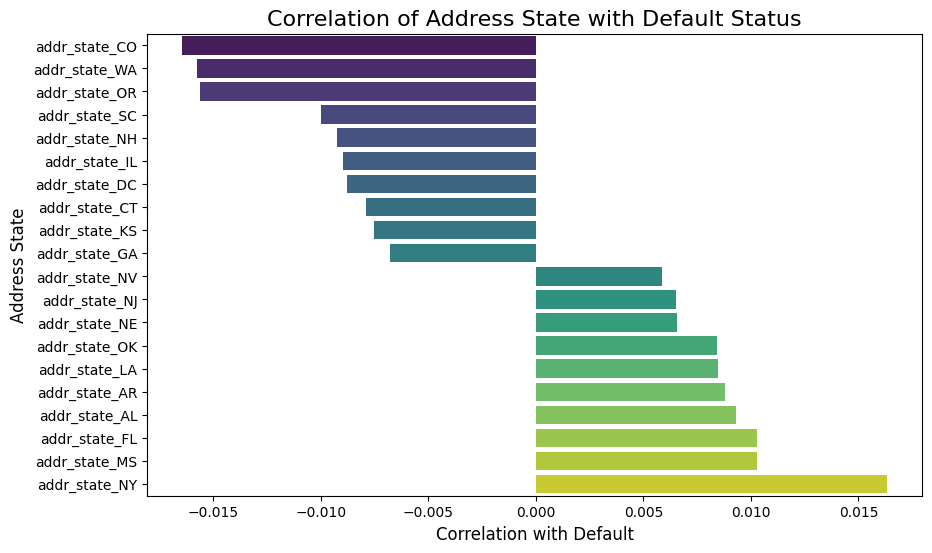

In [13]:
addr_cols = [col for col in df.columns if col.startswith("addr_state_")]
if addr_cols:
    addr_corr = df[addr_cols + ["is_default"]].corr()["is_default"].sort_values()
    addr_corr = addr_corr.drop("is_default")  # Exclude the target itself
    # select only top 10 and bottom 10 correlated states
    addr_corr = pd.concat([addr_corr.head(10), addr_corr.tail(10)])
    plt.figure(figsize=(10, 6))
    sns.barplot(x=addr_corr.values, y=addr_corr.index, palette="viridis")
    plt.title("Correlation of Address State with Default Status", fontsize=16)
    plt.xlabel("Correlation with Default", fontsize=12)
    plt.ylabel("Address State", fontsize=12)
    plt.show()

In [44]:
# Collapse one-hot encoded state columns back to a single column
addr_state_columns = [col for col in df.columns if col.startswith("addr_state_")]
df["addr_state"] = df[addr_state_columns].idxmax(axis=1).str.replace("addr_state_", "")

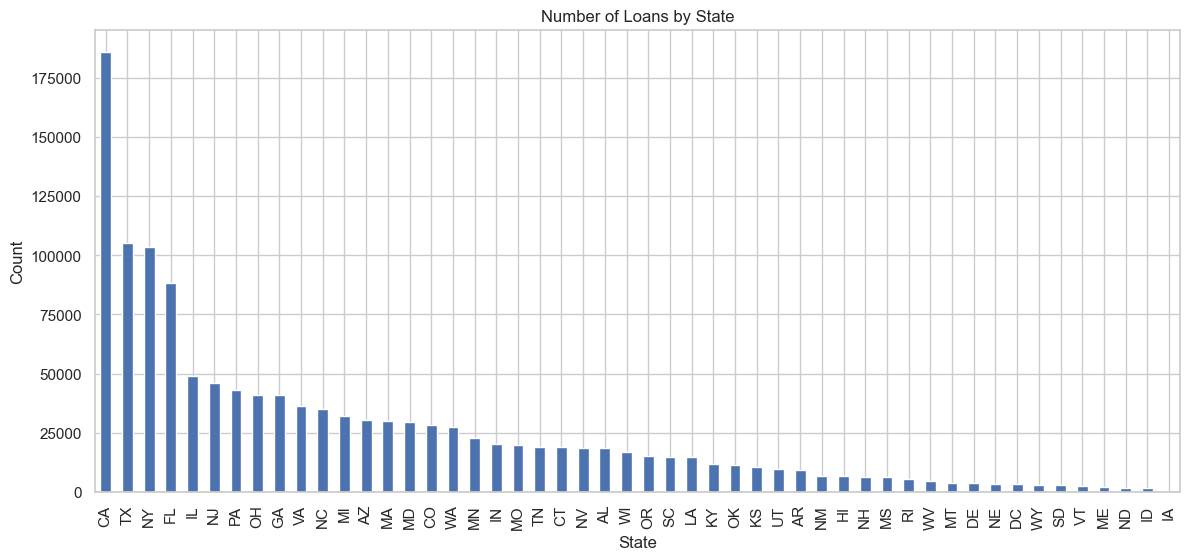

In [45]:
# Plot the distribution of loans across states
plt.figure(figsize=(14, 6))
df["addr_state"].value_counts().sort_values(ascending=False).plot(kind="bar")
plt.title("Number of Loans by State")
plt.ylabel("Count")
plt.xlabel("State")
plt.xticks(rotation=90)
plt.show()

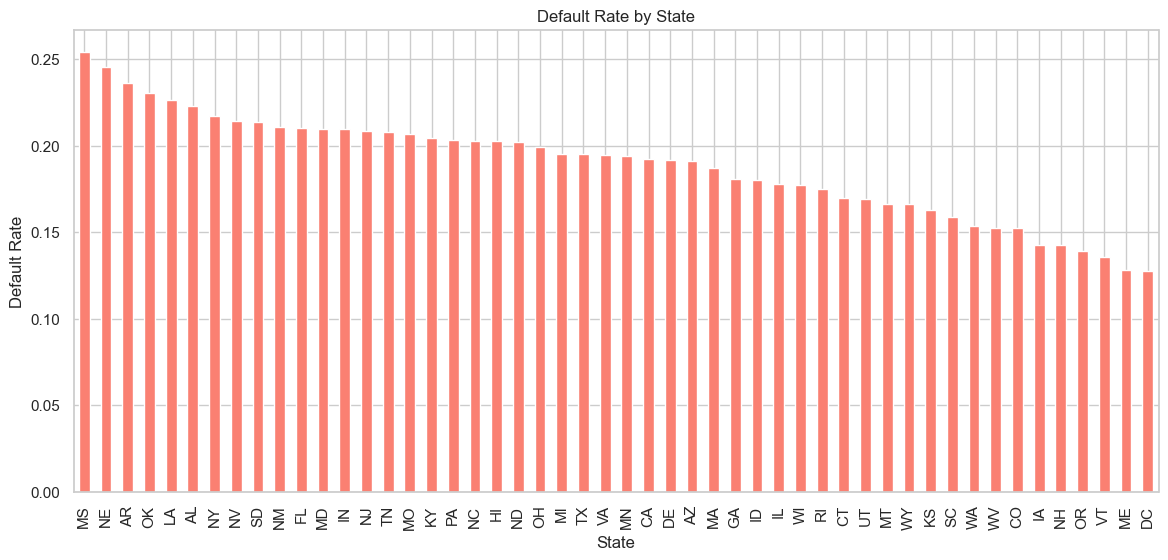

In [46]:
state_default = (
    df.groupby("addr_state")["is_default"].mean().sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))
state_default.plot(kind="bar", color="salmon")
plt.title("Default Rate by State")
plt.ylabel("Default Rate")
plt.xlabel("State")
plt.xticks(rotation=90)
plt.show()

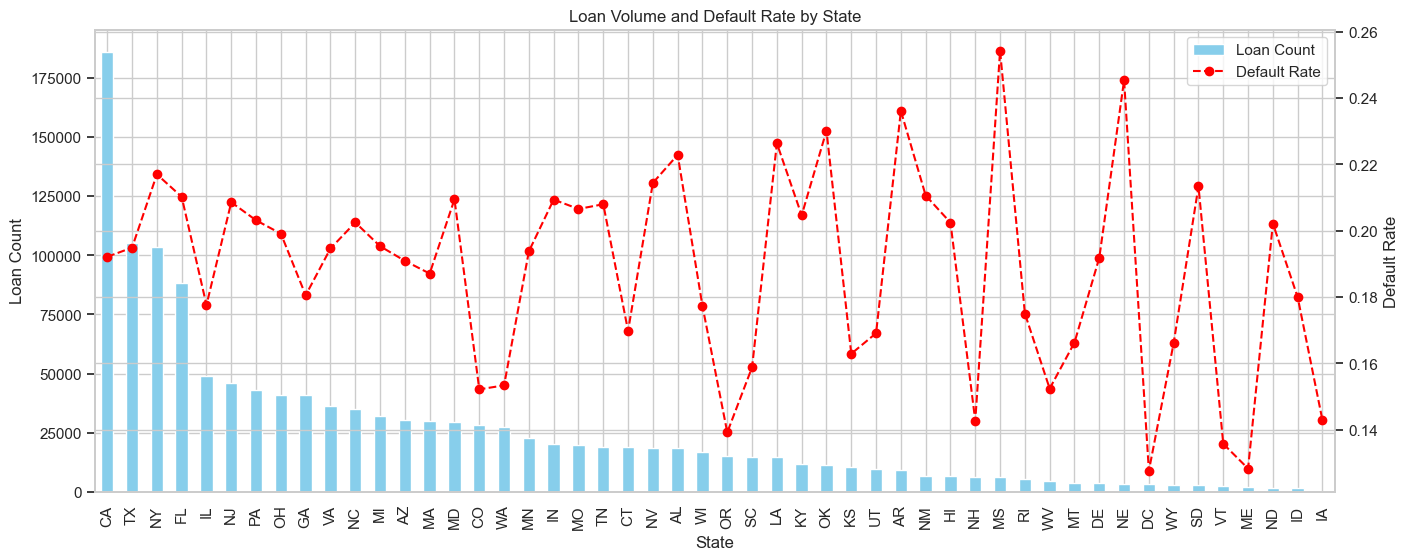

In [47]:
# Combine volume and default rate in a single plot
state_eda = (
    df.groupby("addr_state")
    .agg(loan_count=("is_default", "count"), default_rate=("is_default", "mean"))
    .sort_values("loan_count", ascending=False)
)

fig, ax1 = plt.subplots(figsize=(16, 6))

state_eda["loan_count"].plot(kind="bar", ax=ax1, color="skyblue", label="Loan Count")
ax1.set_ylabel("Loan Count")
ax1.set_xlabel("State")
ax1.set_xticklabels(state_eda.index, rotation=90)

ax2 = ax1.twinx()
state_eda["default_rate"].plot(
    ax=ax2, color="red", label="Default Rate", linestyle="--", marker="o"
)
ax2.set_ylabel("Default Rate")

fig.legend(loc="upper right", bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)
plt.title("Loan Volume and Default Rate by State")
plt.show()